In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/drug-phenotype-cnn")

MODELS_DIR = PROJECT_ROOT / "models"
DATA_DIR = PROJECT_ROOT / "data"
EXAMPLES_DIR = PROJECT_ROOT / "examples"
OUTPUT_DIR = PROJECT_ROOT / "tool_outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODELS_DIR / "resnet18_step8_rerun_sampler_ce_best.pt"
LABEL_MAP_PATH = DATA_DIR / "label_map_min80.csv"
MANIFEST_PATH = EXAMPLES_DIR / "examples_manifest.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("BEST_MODEL_PATH exists:", BEST_MODEL_PATH.exists())
print("LABEL_MAP_PATH exists :", LABEL_MAP_PATH.exists())
print("EXAMPLES_DIR exists   :", EXAMPLES_DIR.exists())
print("OUTPUT_DIR exists     :", OUTPUT_DIR.exists())

PROJECT_ROOT: /content/drive/MyDrive/drug-phenotype-cnn
BEST_MODEL_PATH exists: True
LABEL_MAP_PATH exists : True
EXAMPLES_DIR exists   : True
OUTPUT_DIR exists     : True


In [3]:
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tifffile as tiff

import torch
import torch.nn as nn
from torchvision import models

try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
except ImportError:
    subprocess.check_call(["pip", "-q", "install", "grad-cam"])
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Using device:", device)

Torch version: 2.10.0+cu128
CUDA available: True
Using device: cuda


In [4]:
assert BEST_MODEL_PATH.exists(), f"Missing model checkpoint: {BEST_MODEL_PATH}"
assert LABEL_MAP_PATH.exists(), f"Missing label map: {LABEL_MAP_PATH}"
assert MANIFEST_PATH.exists(), f"Missing examples manifest: {MANIFEST_PATH}"

print("Core inference files found.")

Core inference files found.


In [5]:
# load the label map

label_map_df = pd.read_csv(LABEL_MAP_PATH).sort_values("label_id")

required_cols = {"moa", "label_id"}
missing = required_cols - set(label_map_df.columns)
assert not missing, f"Label map missing columns: {missing}"

class_names = label_map_df["moa"].tolist()
num_classes = len(class_names)

print("Number of classes:", num_classes)
print(label_map_df)

Number of classes: 7
                         moa  label_id
0   Aurora kinase inhibitors         0
1                       DMSO         1
2                 DNA damage         2
3             Eg5 inhibitors         3
4  Microtubule destabilizers         4
5    Microtubule stabilizers         5
6          Protein synthesis         6


In [6]:
# rebuild trained model and load weights

def build_resnet18(num_classes: int):
    model = models.resnet18(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

model = build_resnet18(num_classes=num_classes).to(device)
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

print("Model loaded successfully.")

Model loaded successfully.


In [7]:
# preprocessing pipeline

IMG_SIZE = 256

def read_tiff_grayscale(path: Path) -> np.ndarray:
    img = tiff.imread(str(path))
    if img.ndim != 2:
        raise ValueError(f"Expected 2D grayscale TIFF, got shape {img.shape} for {path}")
    return img

def percentile_clip(img: np.ndarray, low=1.0, high=99.0) -> np.ndarray:
    lo = np.percentile(img, low)
    hi = np.percentile(img, high)
    if hi <= lo:
        return img.astype(np.float32)
    return np.clip(img, lo, hi).astype(np.float32)

def normalize_0_1(img: np.ndarray, eps=1e-6) -> np.ndarray:
    mn = float(np.min(img))
    mx = float(np.max(img))
    if mx - mn < eps:
        return np.zeros_like(img, dtype=np.float32)
    return (img - mn) / (mx - mn)

def resize_hw(img: np.ndarray, out_h: int, out_w: int) -> np.ndarray:
    return cv2.resize(img, (out_w, out_h), interpolation=cv2.INTER_AREA).astype(np.float32)

def preprocess_triplet(path_dapi, path_actin, path_tubulin, out_h=256, out_w=256,
                       clip_low=1.0, clip_high=99.0):
    dapi = read_tiff_grayscale(Path(path_dapi))
    act  = read_tiff_grayscale(Path(path_actin))
    tub  = read_tiff_grayscale(Path(path_tubulin))

    dapi = normalize_0_1(percentile_clip(dapi, clip_low, clip_high))
    act  = normalize_0_1(percentile_clip(act,  clip_low, clip_high))
    tub  = normalize_0_1(percentile_clip(tub,  clip_low, clip_high))

    dapi = resize_hw(dapi, out_h, out_w)
    act  = resize_hw(act,  out_h, out_w)
    tub  = resize_hw(tub,  out_h, out_w)

    return np.stack([dapi, act, tub], axis=0).astype(np.float32)

In [8]:
# helper function for prediction

def make_display_rgb(x_chw: np.ndarray) -> np.ndarray:
    rgb = np.transpose(x_chw, (1, 2, 0))
    return np.clip(rgb, 0.0, 1.0)

def predict_single(model, x_chw: np.ndarray, device):
    x = torch.tensor(x_chw, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()

    pred_id = int(np.argmax(probs))
    pred_name = class_names[pred_id]
    confidence = float(np.max(probs))

    return {
        "pred_id": pred_id,
        "pred_name": pred_name,
        "confidence": confidence,
        "probs": probs
    }

def top_k_predictions(probs: np.ndarray, k: int = 3):
    idx = np.argsort(probs)[::-1][:k]
    return [(int(i), class_names[int(i)], float(probs[int(i)])) for i in idx]

In [9]:
# grad-CAM setup

target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

print("Grad-CAM initialized.")

Grad-CAM initialized.


In [10]:
# full inference function

def predict_phenotype(path_dapi, path_actin, path_tubulin, img_size=256):
    x_chw = preprocess_triplet(
        path_dapi=path_dapi,
        path_actin=path_actin,
        path_tubulin=path_tubulin,
        out_h=img_size,
        out_w=img_size
    )

    pred = predict_single(model, x_chw, device)
    top3 = top_k_predictions(pred["probs"], k=3)

    input_tensor = torch.tensor(x_chw, dtype=torch.float32).unsqueeze(0).to(device)
    targets = [ClassifierOutputTarget(pred["pred_id"])]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    rgb = make_display_rgb(x_chw)
    cam_image = show_cam_on_image(rgb, grayscale_cam, use_rgb=True)

    if pred["confidence"] >= 0.80:
        confidence_note = "High confidence prediction"
    elif pred["confidence"] >= 0.60:
        confidence_note = "Moderate confidence prediction"
    else:
        confidence_note = "Low confidence prediction — phenotype may be ambiguous"

    return {
        "input_tensor_chw": x_chw,
        "display_rgb": rgb,
        "gradcam_overlay": cam_image,
        "predicted_label_id": pred["pred_id"],
        "predicted_label_name": pred["pred_name"],
        "confidence": pred["confidence"],
        "confidence_note": confidence_note,
        "top3": top3,
        "all_probs": pred["probs"]
    }

In [11]:
# load examples
#replace example files with your own files

examples_df = pd.read_csv(MANIFEST_PATH)

required_example_cols = {
    "example_id", "moa", "compound",
    "dapi_file", "actin_file", "tubulin_file"
}
missing = required_example_cols - set(examples_df.columns)
assert not missing, f"Examples manifest missing columns: {missing}"

print("Examples manifest:")
display(examples_df)

Examples manifest:


,example_id,moa,predicted_moa,confidence,compound,dapi_file,actin_file,tubulin_file
0,example1,Aurora kinase inhibitors,Aurora kinase inhibitors,0.999954,AZ-A,example1_dapi.tif,example1_actin.tif,example1_tubulin.tif
1,example2,DMSO,DMSO,1.000000,DMSO,example2_dapi.tif,example2_actin.tif,example2_tubulin.tif
2,example3,Protein synthesis,Protein synthesis,0.999159,cyclohexamide,example3_dapi.tif,example3_actin.tif,example3_tubulin.tif


In [12]:
results_rows = []

for _, row in examples_df.iterrows():
    dapi_path = EXAMPLES_DIR / row["dapi_file"]
    actin_path = EXAMPLES_DIR / row["actin_file"]
    tubulin_path = EXAMPLES_DIR / row["tubulin_file"]

    assert dapi_path.exists(), f"Missing example TIFF: {dapi_path}"
    assert actin_path.exists(), f"Missing example TIFF: {actin_path}"
    assert tubulin_path.exists(), f"Missing example TIFF: {tubulin_path}"

    result = predict_phenotype(
        path_dapi=dapi_path,
        path_actin=actin_path,
        path_tubulin=tubulin_path,
        img_size=IMG_SIZE
    )

    top1 = result["top3"][0]
    top2 = result["top3"][1] if len(result["top3"]) > 1 else (None, None, None)
    top3 = result["top3"][2] if len(result["top3"]) > 2 else (None, None, None)

    results_rows.append({
        "example_id": row["example_id"],
        "true_moa": row["moa"],
        "compound": row["compound"],
        "predicted_moa": result["predicted_label_name"],
        "confidence": result["confidence"],
        "confidence_note": result["confidence_note"],
        "top1_name": top1[1],
        "top1_prob": top1[2],
        "top2_name": top2[1],
        "top2_prob": top2[2],
        "top3_name": top3[1],
        "top3_prob": top3[2],
        "correct": row["moa"] == result["predicted_label_name"],
    })

results_df = pd.DataFrame(results_rows)
results_csv = OUTPUT_DIR / "example_predictions_table.csv"
results_df.to_csv(results_csv, index=False)

print("Saved results table to:", results_csv)
display(results_df)

Saved results table to: /content/drive/MyDrive/drug-phenotype-cnn/tool_outputs/example_predictions_table.csv


,example_id,true_moa,compound,predicted_moa,confidence,confidence_note,top1_name,top1_prob,top2_name,top2_prob,top3_name,top3_prob,correct
0,example1,Aurora kinase inhibitors,AZ-A,Aurora kinase inhibitors,0.999954,High confidence prediction,Aurora kinase inhibitors,0.999954,DNA damage,3.738080e-05,Microtubule stabilizers,6.364346e-06,True
1,example2,DMSO,DMSO,DMSO,1.000000,High confidence prediction,DMSO,1.000000,DNA damage,2.687371e-08,Microtubule destabilizers,1.542544e-08,True
2,example3,Protein synthesis,cyclohexamide,Protein synthesis,0.999162,High confidence prediction,Protein synthesis,0.999162,DMSO,3.533893e-04,Microtubule stabilizers,2.500436e-04,True


In [13]:
# generate grad-CAM figures and save

saved_figures = []

for _, row in examples_df.iterrows():
    dapi_path = EXAMPLES_DIR / row["dapi_file"]
    actin_path = EXAMPLES_DIR / row["actin_file"]
    tubulin_path = EXAMPLES_DIR / row["tubulin_file"]

    result = predict_phenotype(
        path_dapi=dapi_path,
        path_actin=actin_path,
        path_tubulin=tubulin_path,
        img_size=IMG_SIZE
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(result["display_rgb"])
    axes[0].set_title(f"{row['example_id']} — Input composite")
    axes[0].axis("off")

    axes[1].imshow(result["gradcam_overlay"])
    axes[1].set_title(
        f"Grad-CAM\nTrue={row['moa']} | Pred={result['predicted_label_name']} ({result['confidence']:.3f})"
    )
    axes[1].axis("off")

    plt.tight_layout()

    fig_path = OUTPUT_DIR / f"{row['example_id']}_gradcam.png"
    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

    saved_figures.append(fig_path)

print("Saved Grad-CAM figures:")
for p in saved_figures:
    print(" -", p.name)

Saved Grad-CAM figures:
 - example1_gradcam.png
 - example2_gradcam.png
 - example3_gradcam.png


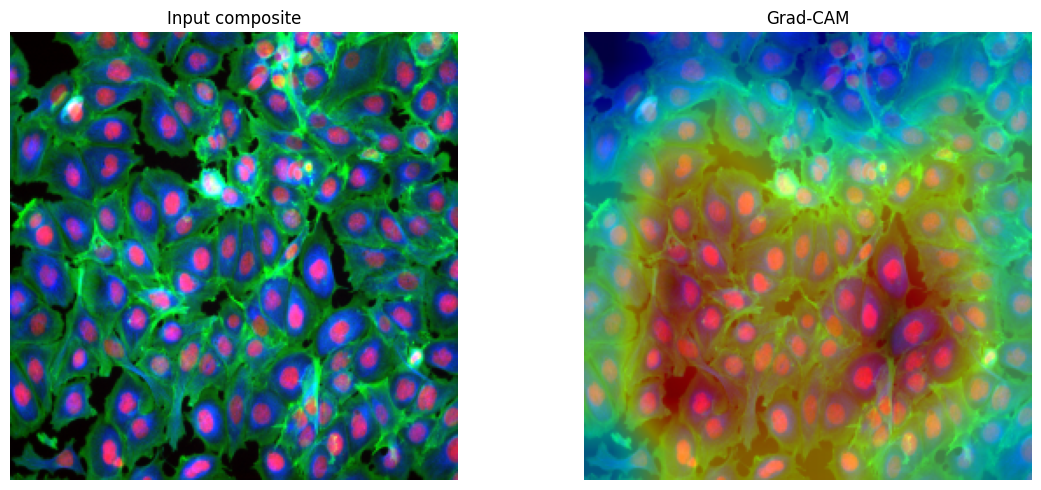

True phenotype: Aurora kinase inhibitors
Predicted phenotype: Aurora kinase inhibitors
Confidence: 1.0000
Confidence note: High confidence prediction

Top-3 predictions:
1. Aurora kinase inhibitors — 1.0000
2. DNA damage — 0.0000
3. Microtubule stabilizers — 0.0000


In [14]:
# one example figure

row = examples_df.iloc[0]

result = predict_phenotype(
    path_dapi=EXAMPLES_DIR / row["dapi_file"],
    path_actin=EXAMPLES_DIR / row["actin_file"],
    path_tubulin=EXAMPLES_DIR / row["tubulin_file"],
    img_size=IMG_SIZE
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(result["display_rgb"])
axes[0].set_title("Input composite")
axes[0].axis("off")

axes[1].imshow(result["gradcam_overlay"])
axes[1].set_title("Grad-CAM")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("True phenotype:", row["moa"])
print("Predicted phenotype:", result["predicted_label_name"])
print("Confidence:", f"{result['confidence']:.4f}")
print("Confidence note:", result["confidence_note"])
print("\nTop-3 predictions:")
for rank, (_, name, prob) in enumerate(result["top3"], start=1):
    print(f"{rank}. {name} — {prob:.4f}")

In [15]:
# Optional user block:
# Uncomment and edit these three lines to use your own TIFF files.

# custom_dapi = Path("/path/to/your_dapi.tif")
# custom_actin = Path("/path/to/your_actin.tif")
# custom_tubulin = Path("/path/to/your_tubulin.tif")

# assert custom_dapi.exists(), f"Missing file: {custom_dapi}"
# assert custom_actin.exists(), f"Missing file: {custom_actin}"
# assert custom_tubulin.exists(), f"Missing file: {custom_tubulin}"

# custom_result = predict_phenotype(
#     path_dapi=custom_dapi,
#     path_actin=custom_actin,
#     path_tubulin=custom_tubulin,
#     img_size=IMG_SIZE
# )

# fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# axes[0].imshow(custom_result["display_rgb"])
# axes[0].set_title("Custom input composite")
# axes[0].axis("off")

# axes[1].imshow(custom_result["gradcam_overlay"])
# axes[1].set_title("Custom Grad-CAM")
# axes[1].axis("off")
# plt.tight_layout()
# plt.show()

# print("Predicted phenotype:", custom_result["predicted_label_name"])
# print("Confidence:", custom_result["confidence"])
# print("Top-3:", custom_result["top3"])